# Road Damage Detection — Dataset Exploration

This notebook performs an exploratory analysis of the RDD2022
(Road Damage Detection 2022) dataset before training an object
detection model.

### Objectives

- Understand the dataset structure and splits
- Inspect image and annotation files
- Analyze class distribution
- Analyze the number and size of bounding boxes
- Visualize ground-truth annotations
- Check annotation integrity
- Understand image dimensions and aspect ratios

The dataset is already provided in YOLO-compatible annotation format,
so this notebook focuses on understanding and validating the data
rather than modifying it.

**Dataset:** RDD2022  
**Task:** Road Damage Object Detection  
**Annotation format:** YOLO

##  Setup

We begin by importing the libraries required for:

- filesystem inspection
- numerical analysis
- tabular analysis
- image processing
- visualization

In [43]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

##  Locate the Dataset

In [9]:
kaggle_input = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022")
for path in kaggle_input.iterdir():
    print(path)

/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT


### Dataset Root

In [17]:
DATASET_ROOT = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")
print("Dataset exists:",DATASET_ROOT.exists())
print("Dataset path:",DATASET_ROOT)

Dataset exists: True
Dataset path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT


## Dataset Structure

RDD2022 is expected to contain separate splits for training,
validation, and testing, with images and YOLO annotation files
stored separately.

In [18]:
from pathlib import Path

DATASET_ROOT = Path(DATASET_ROOT)

print(DATASET_ROOT.name)
for sub in sorted(DATASET_ROOT.iterdir()):
    if sub.is_dir():
        print(f"└── {sub.name}")
        for split in sorted(sub.iterdir()):
            if split.is_dir():
                inner_folders = [f.name for f in sorted(split.iterdir()) if f.is_dir()]
                inner_str = f" ── ({', '.join(inner_folders)})" if inner_folders else ""
                print(f"    ├── {split.name}{inner_str}")

RDD_SPLIT
└── test
    ├── images
    ├── labels
└── train
    ├── images
    ├── labels
└── val
    ├── images
    ├── labels


In [19]:
splits = ["train", "val", "test"]
available_splits = {}

for split in splits:
    split_path = DATASET_ROOT / split
    if split_path.exists():
        available_splits[split] = split_path

print(available_splits)

{'train': PosixPath('/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train'), 'val': PosixPath('/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val'), 'test': PosixPath('/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test')}


## Count Images and Annotations

In [21]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
split_df = pd.DataFrame([
    {
        "split": name,
        "images": sum(1 for p in (path / "images").rglob("*") if p.suffix.lower() in IMAGE_EXTS),
        "labels": sum(1 for p in (path / "labels").rglob("*.txt"))
    }
    for name, path in available_splits.items()
])
split_df

,split,images,labels
0,train,26869,26869
1,val,5758,5758
2,test,5758,5758


### Total Dataset Size

In [25]:
total_images = split_df["images"].sum()
total_labels = split_df["labels"].sum()
print(f"Total images: {total_images}")
print(f"Total label files: {total_labels}")

Total images: 38385
Total label files: 38385


## image-label pairing

In [29]:
for split in splits:
    image_stems = {p.stem for p in (DATASET_ROOT / split / "images").glob("*")}
    label_stems = {p.stem for p in (DATASET_ROOT / split / "labels").glob("*.txt")}

    print(
        f"{split.upper():5} → "
        f"Images without labels: {len(image_stems - label_stems)} | "
        f"Labels without images: {len(label_stems - image_stems)}"
    )

TRAIN → Images without labels: 0 | Labels without images: 0
VAL   → Images without labels: 0 | Labels without images: 0
TEST  → Images without labels: 0 | Labels without images: 0


## Inspect YOLO Annotations

In [30]:
label_files = list((DATASET_ROOT / "train" / "labels").glob("*.txt"))

for file in label_files[:3]:
    print(f"\n{file.name}")
    print(file.read_text()[:500])


India_007873.txt


Norway_007787.txt
4 0.817127 0.709031 0.021159 0.020988
4 0.704079 0.637361 0.054647 0.026727
4 0.769168 0.777882 0.023038 0.020988
4 0.600114 0.665908 0.014512 0.013361
4 0.672612 0.706935 0.019592 0.013410
4 0.747222 0.747167 0.026449 0.012241
4 0.735597 0.654572 0.087753 0.037657
4 0.645348 0.701103 0.012734 0.018077


China_Drone_001196.txt
1 0.593750 0.904297 0.503906 0.078125
0 0.713867 0.858398 0.048828 0.283203



### UNderstanding a YOLO Annotation

Each row represents one object:

    class_id  x_center  y_center  width  height

The bounding-box coordinates are normalized relative to the image
dimensions.

In [31]:
sample_label = label_files[0]

print("File:", sample_label.name)
print(sample_label.read_text())

File: India_007873.txt



## Checking the YAML file

In [72]:
yaml_files = list(DATASET_ROOT.rglob("*.yaml")) + list(DATASET_ROOT.rglob("*.yml"))

yaml_files

[]

## Class Distribution

In [67]:
class_counts = {split: {} for split in splits}

for split in splits:
    for file in (DATASET_ROOT / split / "labels").glob("*.txt"):
        for line in file.read_text().splitlines():
            if line.strip():
                cls = int(line.split()[0])
                class_counts[split][cls] = class_counts[split].get(cls, 0) + 1

class_counts

{'train': {4: 4628, 1: 8386, 0: 18201, 2: 7527, 3: 7554},
 'val': {0: 3890, 2: 1553, 1: 1769, 4: 965, 3: 1564},
 'test': {2: 1537, 0: 3925, 3: 1587, 1: 1675, 4: 951}}

## Class ID Mapping

The dataset does not contain a YAML configuration file defining the
class names. Therefore, the class-ID mapping is verified from the
original RDD2022 dataset documentation rather than assumed from the
Kaggle description.

### Verified Class Mapping

The dataset uses five road-damage classes. The numeric class IDs are
mapped to their corresponding damage categories as follows.

In [69]:
class_names = {
    0: "Longitudinal crack",
    1: "Transverse crack",
    2: "Alligator crack",
    3: "Other corruption",
    4: "Pothole"
}

### Overall Class Distribution

We combine the object counts from the train, validation and test
splits to understand the class distribution of the complete dataset.

In [68]:
overall = {}

for cls in range(5):
    overall[cls] = sum(class_counts[split].get(cls, 0) for split in splits)

overall_df = pd.DataFrame({
    "Class ID": overall.keys(),
    "Objects": overall.values()
})

overall_df["Class"] = overall_df["Class ID"].map(class_names)
overall_df["Percentage"] = (
    overall_df["Objects"] / overall_df["Objects"].sum() * 100
).round(2)

overall_df

,Class ID,Objects,Class,Percentage
0,0,26016,Longitudinal crack,39.59
1,1,11830,Transverse crack,18.00
2,2,10617,Alligator crack,16.16
3,3,10705,Other corruption,16.29
4,4,6544,Pothole,9.96


### Empty background files

In [71]:
empty_labels = {split: 0 for split in available_splits}

for split_name, split_path in available_splits.items():
    for lbl_file in (split_path / "labels").rglob("*.txt"):
        if not lbl_file.read_text().strip():
            empty_labels[split_name] += 1

print("Empty (Background) Files:", empty_labels)

Empty (Background) Files: {'train': 8097, 'val': 1837, 'test': 1790}


**So around 30.5% of all images have no annotated road-damage object.**

### Object Distribution by Class

The bar chart shows the number of annotated objects belonging to
each class.

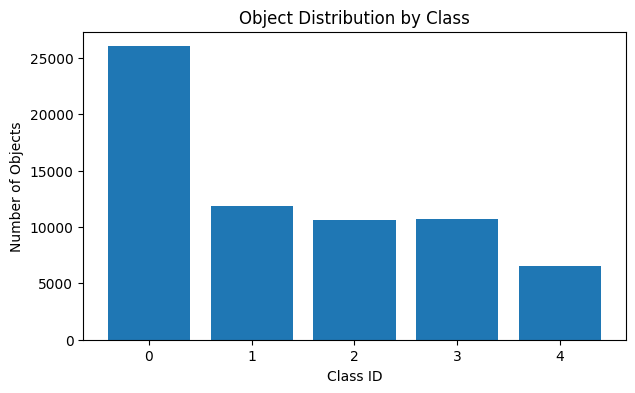

In [36]:
plt.figure(figsize=(7, 4))

plt.bar(
    class_df["Class ID"].astype(str),
    class_df["Objects"]
)

plt.xlabel("Class ID")
plt.ylabel("Number of Objects")
plt.title("Object Distribution by Class")

plt.show()

- class 0 is clearly dominant , while Class 4 is the least represented

In [39]:
import pandas as pd

class_counts = {
    "train": {0: 18201, 1: 8386, 2: 7527, 3: 7554, 4: 4628},
    "val":   {0: 3890,  1: 1769, 2: 1553, 3: 1564, 4: 965},
    "test":  {0: 3925,  1: 1675, 2: 1537, 3: 1587, 4: 951}
}

empty_labels = {"train": 8097, "val": 1837, "test": 1790}
total_images = {"train": 26869, "val": 5758, "test": 5758}

# Build base DataFrame
class_df = pd.DataFrame(class_counts).T
class_df.columns = [f"Class_{c}" for c in class_df.columns]

# Add image and background stats
class_df["Total_Images"] = pd.Series(total_images)
class_df["Background_Images"] = pd.Series(empty_labels)
class_df["Background_Ratio (%)"] = (
    class_df["Background_Images"] / class_df["Total_Images"] * 100
).round(2)

class_df

,Class_0,Class_1,Class_2,Class_3,Class_4,Total_Images,Background_Images,Background_Ratio (%)
train,18201,8386,7527,7554,4628,26869,8097,30.14
val,3890,1769,1553,1564,965,5758,1837,31.90
test,3925,1675,1537,1587,951,5758,1790,31.09


## Objects per class

In [40]:
objects_per_image = {}

for split in splits:
    counts = []

    for file in (DATASET_ROOT / split / "labels").glob("*.txt"):
        lines = [x for x in file.read_text().splitlines() if x.strip()]
        counts.append(len(lines))

    objects_per_image[split] = counts

    print(
        split.upper(),
        "→ Mean:", round(np.mean(counts), 2),
        "| Median:", np.median(counts),
        "| Max:", max(counts)
    )

TRAIN → Mean: 1.72 | Median: 1.0 | Max: 44
VAL → Mean: 1.69 | Median: 1.0 | Max: 34
TEST → Mean: 1.68 | Median: 1.0 | Max: 26


The dataset exhibits a sparse object density across all splits, with an average of ~1.7 defects per frame and a median of 1.0, indicating most images contain single, isolated damages rather than crowded scenes. The near-identical means (1.72 vs 1.69 vs 1.68) confirm a balanced distribution without split bias, while high maximums (up to 44) reflect occasional severe road deterioration that YOLO's default detection limits and mosaic augmentations can easily accommodate.

### Objects-per-Image Distribution

The distribution shows how frequently images contain different
numbers of annotated road-damage objects.

In [53]:
train_labels_dir = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels")
train_lbl_files = list(train_labels_dir.rglob("*.txt"))

# Extract count of lines (boxes) per image file
train_counts = []
for file in train_lbl_files:
    content = file.read_text().strip()
    train_counts.append(len(content.splitlines()) if content else 0)

print(f"Total images : {len(train_counts)}")

Total images : 26869


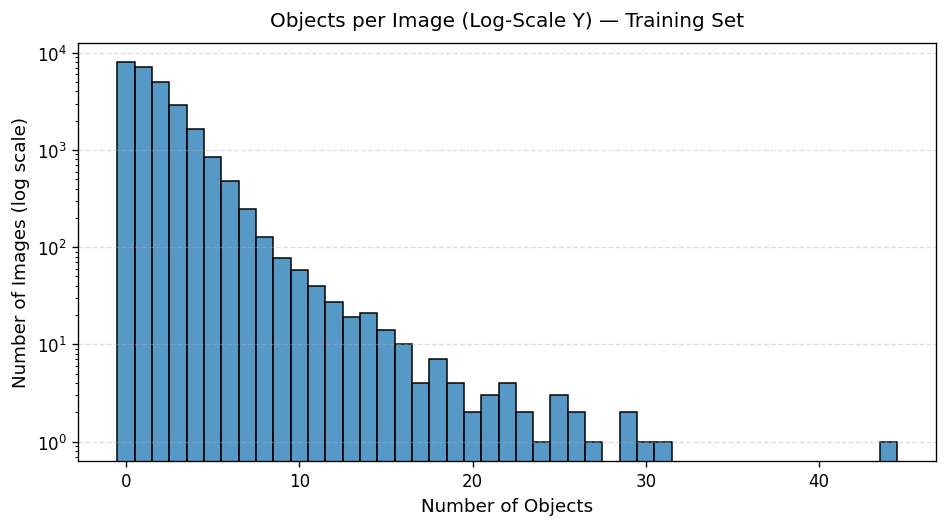

In [54]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)

sns.histplot(
    train_counts,
    discrete=True,
    color="#1f77b4",
    edgecolor="black",
    ax=ax
)

ax.set_yscale("log")
ax.set_title("Objects per Image (Log-Scale Y) — Training Set", fontsize=12, pad=10)
ax.set_xlabel("Number of Objects", fontsize=11)
ax.set_ylabel("Number of Images (log scale)", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

That lone bar sitting far out at 44 represents a single image with an unusually dense cluster of annotations.

## Inspect the outlier image

In [55]:
# Find which file has 44 objects
outlier_files = []
for file in train_lbl_files:
    content = file.read_text().strip()
    if content and len(content.splitlines()) == 44:
        outlier_files.append(file.name)

print(f"File with 44 annotations: {outlier_files}")

File with 44 annotations: ['Norway_003110.txt']


## Bounding Box 

## Bounding Box Characteristics

Each YOLO annotation contains:

    class_id x_center y_center width height

We collect these values for every annotated object so that we can
analyze the spatial location, size and shape of bounding boxes.

In [76]:
box_data = []

for split in splits:
    for file in (DATASET_ROOT / split / "labels").glob("*.txt"):
        for line in file.read_text().splitlines():
            if line.strip():
                cls, xc, yc, w, h = map(float, line.split())
                box_data.append([split, int(cls), xc, yc, w, h])

box_df = pd.DataFrame(
    box_data,
    columns=["Split", "Class ID", "X Center", "Y Center", "Width", "Height"]
)

box_df["Class"] = box_df["Class ID"].map(class_names)

box_df.head()

,Split,Class ID,X Center,Y Center,Width,Height,Class
0,train,4,0.817127,0.709031,0.021159,0.020988,Pothole
1,train,4,0.704079,0.637361,0.054647,0.026727,Pothole
2,train,4,0.769168,0.777882,0.023038,0.020988,Pothole
3,train,4,0.600114,0.665908,0.014512,0.013361,Pothole
4,train,4,0.672612,0.706935,0.019592,0.013410,Pothole


In [77]:
box_df["Area"] = box_df["Width"] * box_df["Height"]

box_df[["Width", "Height", "Area"]].describe()

,Width,Height,Area
count,65712.000000,65712.000000,65712.000000
mean,0.210250,0.165883,0.046118
std,0.204611,0.161809,0.079648
min,0.000000,0.001667,0.000000
25%,0.070312,0.050000,0.004825
50%,0.141667,0.113281,0.015176
75%,0.277344,0.231250,0.049783
max,0.999023,0.998047,0.940847


## Spatial Distribution of Bounding Boxes

Visualizing the center coordinates of all annotated bounding boxes.

The heatmap shows where road-damage objects tend to appear within
the image.

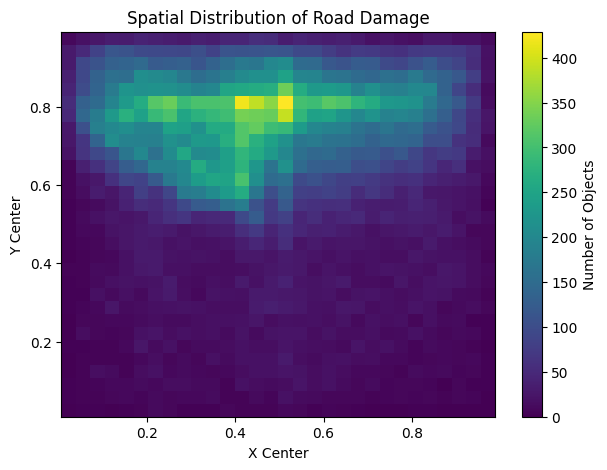

In [78]:
plt.figure(figsize=(7, 5))

plt.hist2d(
    box_df["X Center"],
    box_df["Y Center"],
    bins=30
)

plt.xlabel("X Center")
plt.ylabel("Y Center")
plt.title("Spatial Distribution of Road Damage")
plt.colorbar(label="Number of Objects")

plt.show()

### Spatial Distribution Analysis
- **Road Surface Localization:** Defects are concentrated heavily in the lower half of the camera frame ($y \in [0.65, 0.90]$), with the primary hotspot centered directly in the vehicle's driving lane ($x \approx 0.40\text{–}0.55$).
- **High Label Quality:** The upper region ($y < 0.40$, representing sky and horizon) shows virtually zero annotations, confirming no noise or false bounding boxes in non-road regions.

## Bounding Box Aspect Ratio

The aspect ratio of a bounding box is defined as:

    Aspect Ratio = Width / Height

We compare the aspect-ratio distributions across classes to understand
differences in the shapes of road-damage objects.

In [79]:
box_df["Aspect Ratio"] = box_df["Width"] / box_df["Height"]

box_df[["Class", "Aspect Ratio"]].head()

,Class,Aspect Ratio
0,Pothole,1.008148
1,Pothole,2.044637
2,Pothole,1.097675
3,Pothole,1.086146
4,Pothole,1.460999


### Aspect Ratio Distribution Across Classes

The boxplot compares the distribution of bounding-box aspect ratios
for each road-damage class.

<Figure size 1000x500 with 0 Axes>

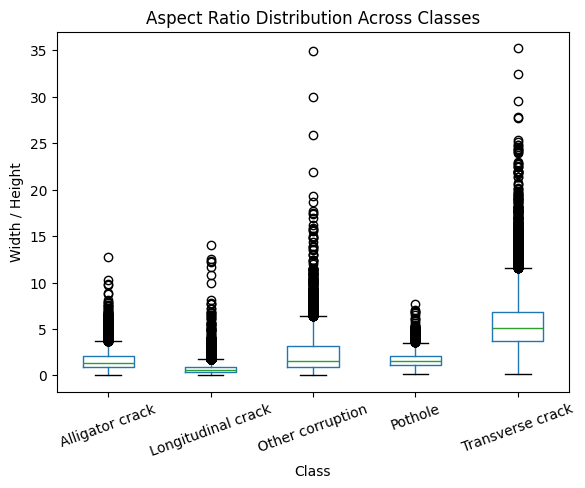

In [80]:
plt.figure(figsize=(10, 5))

box_df.boxplot(
    column="Aspect Ratio",
    by="Class",
    grid=False
)

plt.xlabel("Class")
plt.ylabel("Width / Height")
plt.title("Aspect Ratio Distribution Across Classes")
plt.suptitle("")
plt.xticks(rotation=20)

plt.show()

### Aspect Ratio ($w/h$) Distribution by Class

* **Geometric Discrimination:** Classes exhibit clear spatial geometry—**Transverse Cracks** are heavily wide-oriented (median $w/h \approx 5.0$), while **Longitudinal Cracks** are vertically oriented (median $w/h < 1.0$).
* **Isotropic Classes:** **Potholes** and **Alligator Cracks** remain roughly square (median $w/h \approx 1.0\text{–}1.3$) with tight spreads.
* **Model Training Implication:** High variance in aspect ratios (ranging from $<0.2$ to $>30$) validates the use of anchor-free architectures (like YOLOv8) and CIoU loss to effectively regress both extreme horizontal streaks and narrow vertical lines.

## Bounding Box Width vs Height

We visualize normalized bounding-box width against height for each
road-damage class.

This helps us understand differences in object size and shape
between classes.

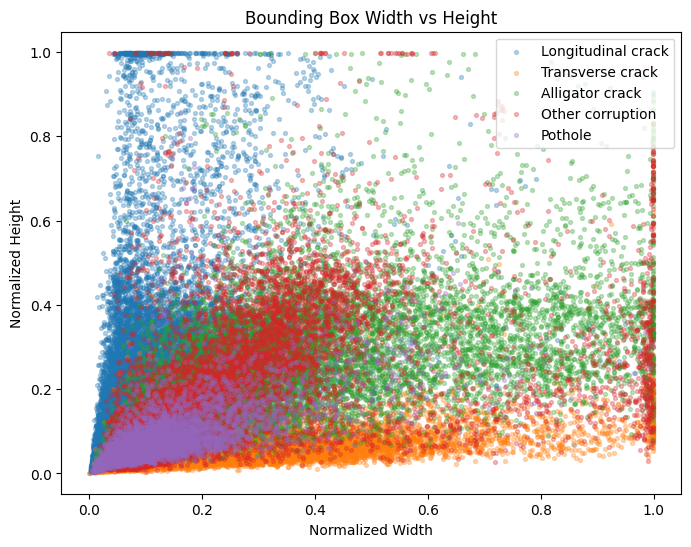

In [81]:
plt.figure(figsize=(8, 6))

for cls, name in class_names.items():
    data = box_df[box_df["Class ID"] == cls]

    plt.scatter(
        data["Width"],
        data["Height"],
        s=8,
        alpha=0.3,
        label=name
    )

plt.xlabel("Normalized Width")
plt.ylabel("Normalized Height")
plt.title("Bounding Box Width vs Height")
plt.legend()

plt.show()

### Class Clustering Breakdown

* **Longitudinal Crack (Blue):**
  * Clustered along vertical axis ($w \in [0.0, 0.2], h \le 1.0$).
  * Narrow and tall, following vehicle perspective.

* **Transverse Crack (Orange):**
  * Clustered along horizontal axis ($h \in [0.0, 0.15], w \in [0.1, 1.0]$).
  * Wide horizontal streaks across road lanes.

* **Pothole (Purple):**
  * Clustered near origin ($w, h \le 0.25$).
  * Small, compact, and isotropic defects.

* **Alligator Crack (Green) & Other Corruption (Red):**
  * Dispersed across center ($w \in [0.1, 0.8], h \in [0.1, 0.6]$).
  * Multi-scale surface distress expanding in both dimensions.

* **Boundary Artifacts ($w = 1.0$ or $h = 1.0$):**
  * Border clusters indicate large defects truncated at image edges.

In [82]:
class_box_summary = box_df.groupby("Class").agg(
    Objects=("Class ID", "size"),
    Mean_Width=("Width", "mean"),
    Mean_Height=("Height", "mean"),
    Mean_Area=("Area", "mean"),
    Median_Aspect_Ratio=("Aspect Ratio", "median")
).round(4)

class_box_summary

,Objects,Mean_Width,Mean_Height,Mean_Area,Median_Aspect_Ratio
Class,,,,,
Alligator crack,10617,0.3891,0.2641,0.1217,1.3610
Longitudinal crack,26016,0.1037,0.1905,0.0263,0.5522
Other corruption,10705,0.2551,0.1832,0.0655,1.5644
Pothole,6544,0.1267,0.0786,0.0153,1.6000
Transverse crack,11830,0.2898,0.0562,0.0213,5.0754


## Bonding box visualization

## 1. Ground-Truth Bounding Box Visualization

We visualize sample images together with their ground-truth
bounding boxes.

The samples include images with different numbers of objects so
that we can visually verify the annotations across different
scenarios.

In [83]:
import random

image_files = list((DATASET_ROOT / "train" / "images").glob("*"))

samples = random.sample(image_files, 6)

### Visualizing the Annotations

YOLO stores bounding boxes using normalized coordinates:

    x_center, y_center, width, height

convert these normalized coordinates into pixel coordinates
before drawing the bounding boxes on the original image.

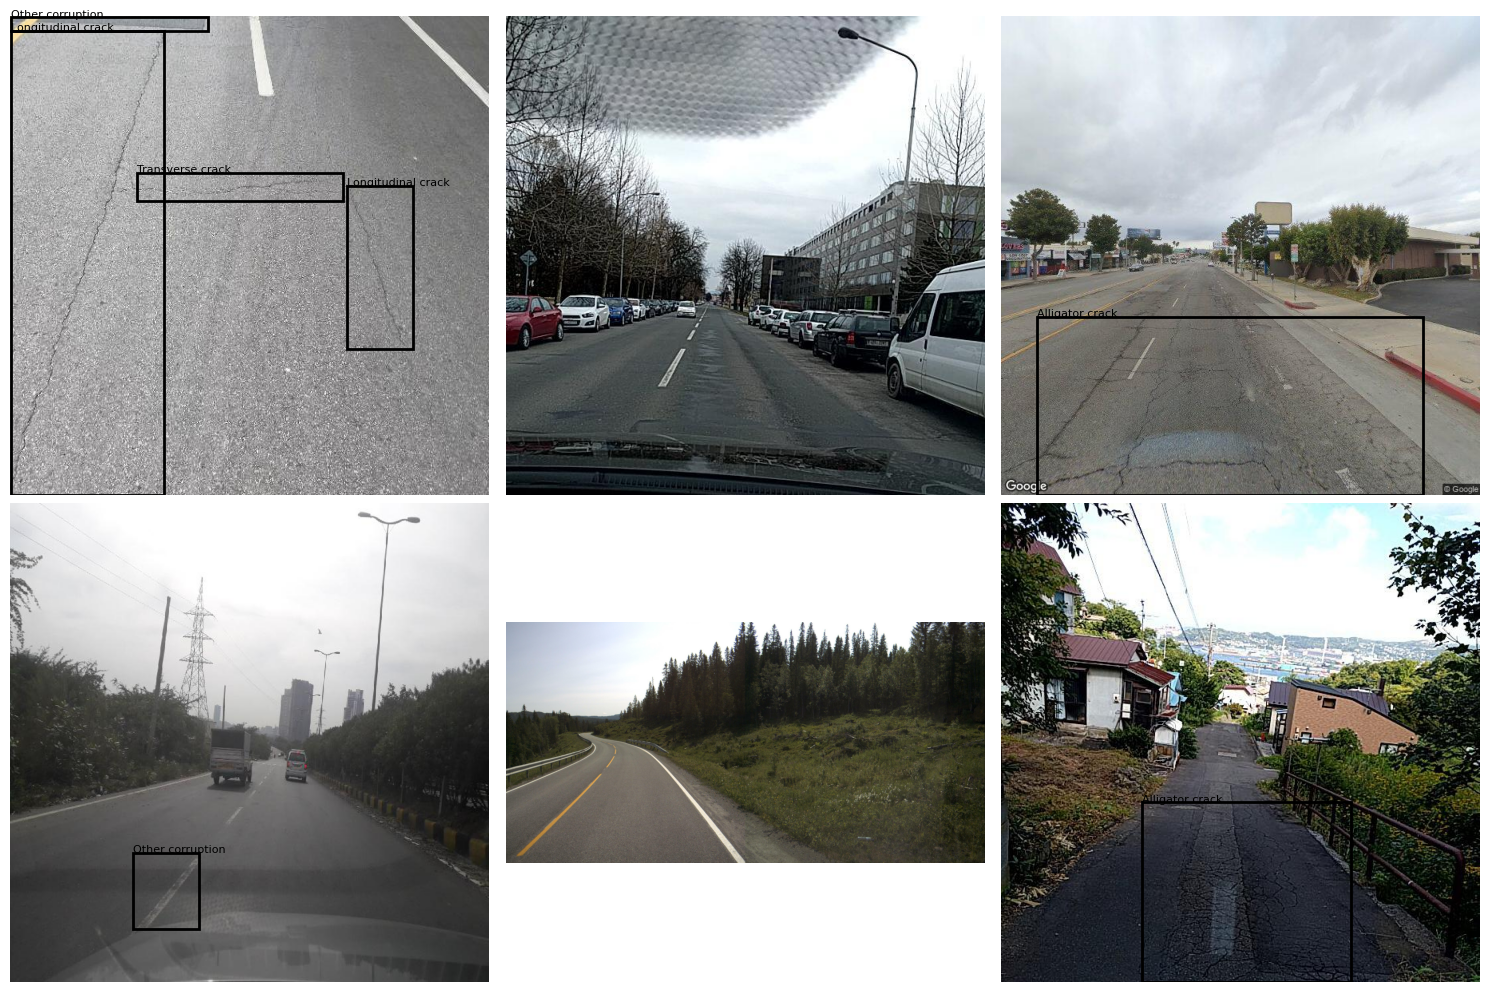

In [84]:
plt.figure(figsize=(15, 10))

for i, image_path in enumerate(samples):

    image = Image.open(image_path)
    label_path = DATASET_ROOT / "train" / "labels" / f"{image_path.stem}.txt"
    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(image)
    img_w, img_h = image.size
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, xc, yc, w, h = map(float, line.split())
            x = (xc - w / 2) * img_w
            y = (yc - h / 2) * img_h
            bw = w * img_w
            bh = h * img_h
            rect = plt.Rectangle((x, y), bw, bh,fill=False,linewidth=2)
            ax.add_patch(rect)
            ax.text(x, y,class_names[int(cls)],fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Background Image Example

Some images contain no annotated road-damage objects and therefore
have empty annotation files.

We visualize one such image to verify that these images are valid
background examples rather than incorrectly formatted annotations.

In [85]:
empty_labels = [
    p for p in (DATASET_ROOT / "train" / "labels").glob("*.txt")
    if not p.read_text().strip()
]

empty_label = random.choice(empty_labels)
empty_image = DATASET_ROOT / "train" / "images" / f"{empty_label.stem}.jpg"

print(empty_image.name)

India_004088.jpg


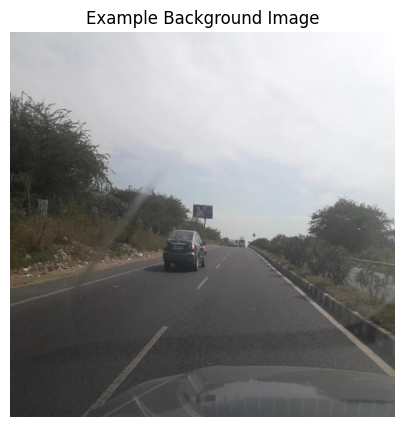

In [86]:
image = Image.open(empty_image)

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Example Background Image")
plt.show()

## Annotation Integrity Check

Before training, we verify that the YOLO annotations satisfy the
expected format and coordinate constraints.

We check:

- exactly 5 values per annotation
- valid class IDs
- normalized center coordinates
- positive bounding-box width and height
- width and height within the normalized image range

In [87]:
invalid = 0

for split in splits:

    for file in (DATASET_ROOT / split / "labels").glob("*.txt"):

        for line in file.read_text().splitlines():

            if not line.strip():
                continue

            values = line.split()

            if len(values) != 5:
                invalid += 1
                continue

            cls, xc, yc, w, h = map(float, values)

            if (
                int(cls) not in class_names
                or not 0 <= xc <= 1
                or not 0 <= yc <= 1
                or not 0 < w <= 1
                or not 0 < h <= 1
            ):
                invalid += 1

print("Invalid annotations:", invalid)

Invalid annotations: 1


## Bounding Boxes Touching Image Boundaries

Some bounding boxes may extend exactly to an image boundary.

We check how frequently normalized bounding-box width or height
reaches 1.0. This helps identify whether the boundary values are
common characteristics of the annotations or potential annotation
issues.

In [88]:
boundary = (
    (box_df["Width"] == 1) |
    (box_df["Height"] == 1)
)

print(f"Boundary boxes: {boundary.sum():,}")
print(f"Percentage: {boundary.mean() * 100:.2f}%")

Boundary boxes: 0
Percentage: 0.00%


In [89]:
box_df[boundary]["Class"].value_counts()

Series([], Name: count, dtype: int64)